In [2]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
%matplotlib inline

## Άσκηση - Απόκριση Μηδενικής Εισόδου (Zero-Input Response)

Πριν ξεκινήσετε, είναι καλή ιδέα να δείτε την άσκηση $\texttt{Ex-DifferentialEquations}$, όπου υλοποιήσαμε μια διαφορική εξίσωση με τη μέθοδο του Euler και μελετήσαμε την έξοδό της για **μηδενικές** αρχικές συνθήκες. 

Εδώ θα εστιάσουμε σε μια θεμελιώδη έννοια των συστημάτων που περιγράφονται από διαφορικές εξισώσεις: την **απόκριση μηδενικής εισόδου** (zero-input response, ZIR).

Η συνολική απόκριση ενός συστήματος που περιγράφεται από διαφορικές εξισώσεις γράφεται πάντα ως άθροισμα δύο όρων:

$$ y(t) = \underbrace{y_{zi}(t)}_{\text{μηδενικής εισόδου}} + \underbrace{y_{zs}(t)}_{\text{μηδενικής κατάστασης}} $$

Ο πρώτος όρος οφείλεται **αποκλειστικά** στις αρχικές συνθήκες — δηλ. στην ενέργεια που είναι ήδη αποθηκευμένη στο σύστημα — με την είσοδο μηδενική, $x(t)=0$. Ο δεύτερος οφείλεται αποκλειστικά στην είσοδο, με μηδενικές αρχικές συνθήκες (θέμα άλλης άσκησης, $\texttt{Ex-ZeroStateResponse}$).

Σ’ αυτή την άσκηση απομονώνουμε τον **πρώτο** όρο: θέτουμε $x(t)=0$ και αφήνουμε το σύστημα να "τρέξει" μόνο από τις αρχικές του συνθήκες.

Για να γίνει η ZIR πιο ενδιαφέρουσα, θα δουλέψουμε με ένα σύστημα **δεύτερης τάξης** — π.χ. ένα κύκλωμα $RLC$ ή ένα μηχανικό σύστημα μάζας–ελατηρίου–αποσβεστήρα (σαν την ανάρτηση του αυτοκινήτου σας):

$$ \frac{d^2 y(t)}{dt^2} + 2\zeta\omega_n \frac{dy(t)}{dt} + \omega_n^2\, y(t) = \omega_n^2\, x(t) $$

με φυσική συχνότητα $\omega_n = 4$ rad/s και συντελεστή απόσβεσης $\zeta=0.25$ (υπο-απόσβεσης, *underdamped*). Αντικαθιστώντας ($2\zeta\omega_n=2$, $\omega_n^2=16$):

$$ \frac{d^2 y}{dt^2} + 2\frac{dy}{dt} + 16\, y = 16\, x(t) $$

Για την απόκριση μηδενικής εισόδου θέτουμε $x(t)=0$ και **μη μηδενικές** αρχικές συνθήκες $y(0)=1$, $\dot y(0)=0$ (π.χ. μια μάζα που ξεκινά εκτοπισμένη κατά 1 μονάδα και αφήνεται ελεύθερη να ταλαντωθεί).

Η μέθοδος Euler εφαρμόζεται σε εξισώσεις **πρώτης** τάξης. Γράφουμε λοιπόν τη δεύτερης τάξης εξίσωση ως **σύστημα δύο εξισώσεων πρώτης τάξης**, εισάγοντας τις **μεταβλητές κατάστασης** $y_1(t)=y(t)$ (θέση/τάση) και $y_2(t)=\dot y(t)$ (ταχύτητα/ρεύμα):

\begin{align*}
    \dot y_1 &= y_2 \\
    \dot y_2 &= -\omega_n^2\, y_1 - 2\zeta\omega_n\, y_2 + \omega_n^2\, x
\end{align*}

Εφαρμόζοντας τον ίδιο ορισμό της παραγώγου όπως και στην άσκηση $\texttt{Ex-DifferentialEquations}$, 

$$\dot y \approx \dfrac{y((n+1)T_s)-y(nT_s)}{T_s}$$

παίρνουμε το **ζεύγος αναδρομικών σχέσεων**:

\begin{align}
    y_1(n+1) &= y_1(n) + T_s\, y_2(n) \\
    y_2(n+1) &= y_2(n) + T_s\left(-\omega_n^2\, y_1(n) - 2\zeta\omega_n\, y_2(n) + \omega_n^2\, x(n)\right)
\end{align}

Με την είσοδο $x(n)=0$, οι σχέσεις αυτές μας δίνουν την προσέγγιση της απόκρισης μηδενικής εισόδου.

Σας δίνεται ότι, για $x(t)=0$ και το υπο-αποσβεσμένο σύστημα, η θεωρητική λύση (απόκριση μηδενικής εισόδου) είναι μια **φθίνουσα ταλάντωση**:

$$ y_{zi}(t) = e^{-\sigma t}\left[\, y(0)\cos(\omega_d t) + \frac{\dot y(0) + \sigma\, y(0)}{\omega_d}\sin(\omega_d t)\right] $$

όπου $\sigma=\zeta\omega_n=1$ (ρυθμός απόσβεσης) και $\omega_d=\omega_n\sqrt{1-\zeta^2}\approx 3.873$ rad/s (συχνότητα αποσβεσμένης ταλάντωσης). Η περίοδος της ταλάντωσης είναι $T_d = 2\pi/\omega_d \approx 1.62$ s.

Ακολουθεί ο κώδικας για $T_s=0.1$ s. Καλείστε να υλοποιήσετε το ζεύγος των αναδρομικών σχέσεων και να συγκρίνετε με τη θεωρία.

In [6]:
Ts = 0.1                                  # Περίοδος δειγματοληψίας
t  = np.arange(start=0, stop=5, step=Ts)  # Διάνυσμα χρόνου t

# --- Παράμετροι συστήματος ---
wn    = 4.0                               # φυσική συχνότητα ω_n
zeta  = 0.25                              # συντελεστής απόσβεσης ζ
sigma = zeta*wn                           # ρυθμός απόσβεσης σ = ζω_n
wd    = wn*np.sqrt(1 - zeta**2)           # αποσβεσμένη συχνότητα ω_d

# --- Αρχικές συνθήκες (ΜΗ μηδενικές!) ---
y0 = 1.0                                  # y(0)
v0 = 0.0                                  # y'(0)

# --- Είσοδος: ΜΗΔΕΝΙΚΗ (zero-input) ---
x = np.zeros(len(t))                      # x(t) = 0

# --- Θεωρητική απόκριση μηδενικής εισόδου ---
y_theory = np.exp(-sigma*t)*(y0*np.cos(wd*t) + (v0 + sigma*y0)/wd*np.sin(wd*t))

# --- Προσεγγιστική λύση (Euler με 2 μεταβλητές κατάστασης) ---
y1 = np.zeros(len(t))                     # y1 = y   (θέση)
y2 = np.zeros(len(t))                     # y2 = y'  (ταχύτητα)

y1[0] = y0                                # Αρχικοποίηση θέσης
y2[0] = v0                                # Αρχικοποίηση ταχύτητας
for n in range(0, len(t)-1):              # For loop - ζεύγος αναδρομικών σχέσεων
    y1[n+1] = y1[n] + Ts*y2[n]
    y2[n+1] = y2[n] + Ts*(-wn**2*y1[n] - 2*zeta*wn*y2[n] + wn**2*x[n])

y = y1                                    # Η έξοδός μας είναι η μεταβλητή θέσης

Απεικονίζουμε το **απόλυτο** σφάλμα $|y-y_{true}|$.

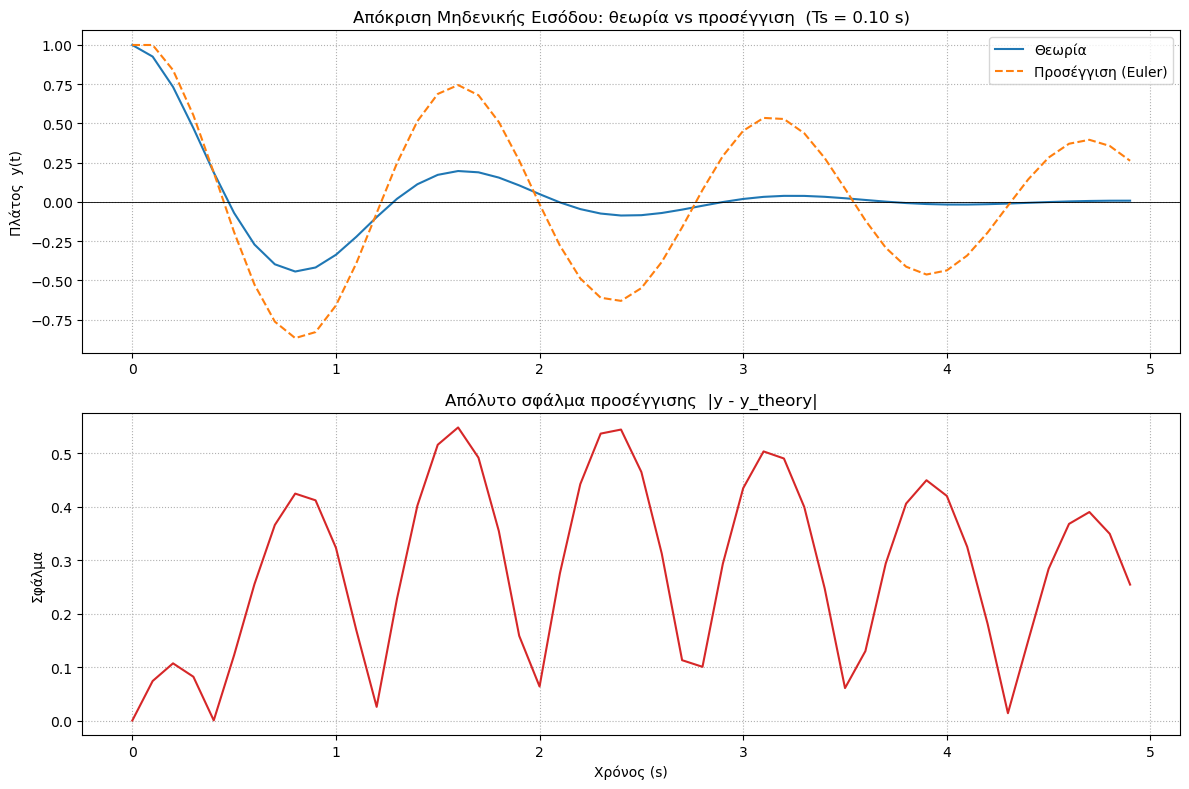

In [7]:
# Γραφήματα
plt.figure(figsize = (12,8))
plt.subplot(2, 1, 1)
plt.plot(t, y_theory, '-',  label="Θεωρία")
plt.plot(t, y,        '--', label="Προσέγγιση (Euler)")
plt.axhline(0, color='k', linewidth=0.6)
plt.grid(linestyle=':')
plt.title('Απόκριση Μηδενικής Εισόδου: θεωρία vs προσέγγιση  (Ts = %.2f s)' % Ts)
plt.ylabel('Πλάτος  y(t)')
plt.legend(loc='upper right')

# Απόλυτο σφάλμα
err_abs = np.abs(y - y_theory)

plt.subplot(2, 1, 2)
plt.plot(t, err_abs, color='tab:red')
plt.grid(linestyle=':')
plt.title('Απόλυτο σφάλμα προσέγγισης  |y - y_theory|')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Σφάλμα')
plt.tight_layout()
plt.show()

Επαναλάβετε το παραπάνω για $T_s = 0.01$ s και τυπώστε τα αντίστοιχα γραφήματα.

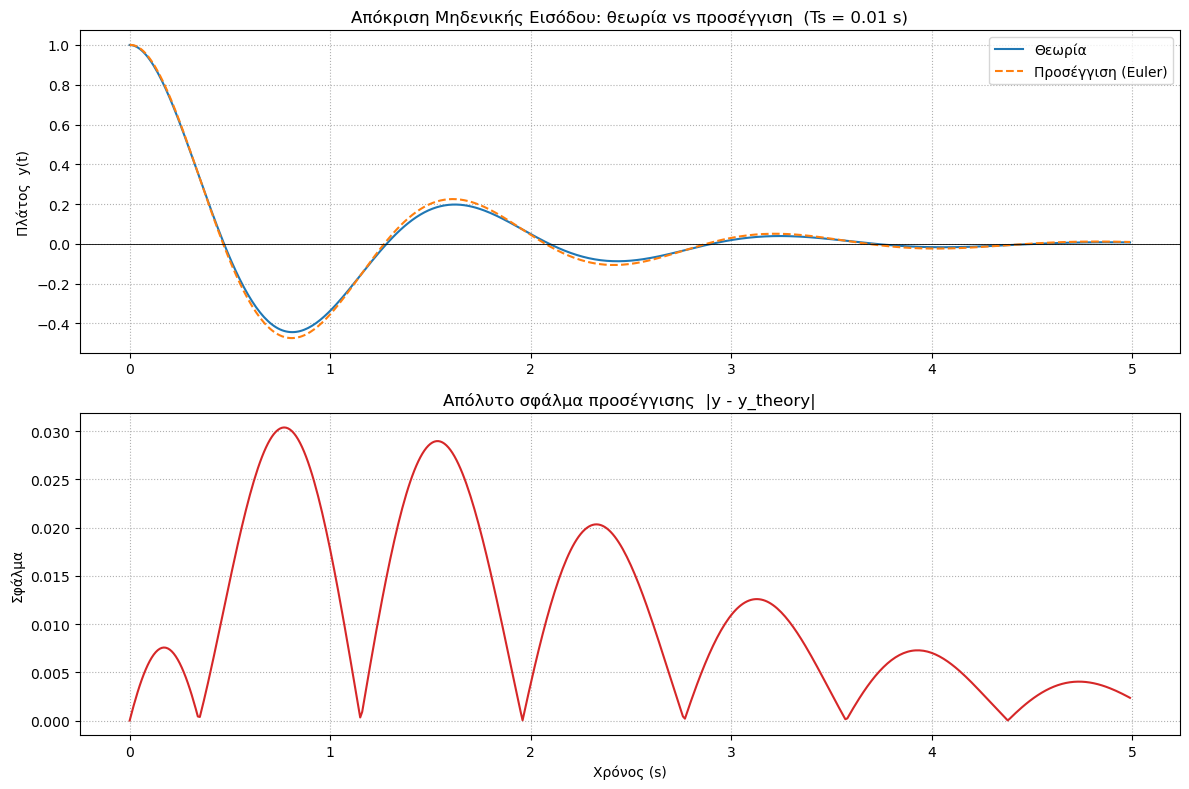

In [10]:
# INSERT CODE HERE
Ts = 0.01                                 # Περίοδος δειγματοληψίας
t  = np.arange(start=0, stop=5, step=Ts)  # Διάνυσμα χρόνου t

wn    = 4.0
zeta  = 0.25
sigma = zeta*wn
wd    = wn*np.sqrt(1 - zeta**2)

y0 = 1.0
v0 = 0.0
x  = np.zeros(len(t))                     # ΜΗΔΕΝΙΚΗ είσοδος

y_theory = np.exp(-sigma*t)*(y0*np.cos(wd*t) + (v0 + sigma*y0)/wd*np.sin(wd*t))

y1 = np.zeros(len(t)); y2 = np.zeros(len(t))
y1[0] = y0; y2[0] = v0
for n in range(0, len(t)-1):
    y1[n+1] = y1[n] + Ts*y2[n]
    y2[n+1] = y2[n] + Ts*(-wn**2*y1[n] - 2*zeta*wn*y2[n] + wn**2*x[n])
y = y1

# Γραφήματα
plt.figure(figsize = (12,8))
plt.subplot(2, 1, 1)
plt.plot(t, y_theory, '-',  label="Θεωρία")
plt.plot(t, y,        '--', label="Προσέγγιση (Euler)")
plt.axhline(0, color='k', linewidth=0.6)
plt.grid(linestyle=':')
plt.title('Απόκριση Μηδενικής Εισόδου: θεωρία vs προσέγγιση  (Ts = %.2f s)' % Ts)
plt.ylabel('Πλάτος  y(t)')
plt.legend(loc='upper right')

err_abs = np.abs(y - y_theory)
plt.subplot(2, 1, 2)
plt.plot(t, err_abs, color='tab:red')
plt.grid(linestyle=':')
plt.title('Απόλυτο σφάλμα προσέγγισης  |y - y_theory|')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Σφάλμα')
plt.tight_layout()
plt.show()
# END OF CODE

Τι παρατηρείτε για την προσέγγιση για τις δύο τιμές του $T_s$; Πώς επηρεάζει η ταλαντωτική φύση του συστήματος δεύτερης τάξης την ακρίβεια, σε σχέση με το πρώτης τάξης παράδειγμα; Γράψτε την απάντησή σας σε αυτό το κελί:

### Απάντηση:

Για $T_s=0.1$ s η προσέγγιση Euler εμφανίζει ορατό σφάλμα τόσο στο **πλάτος** όσο και στη **φάση** της ταλάντωσης: η μέθοδος Euler αποσβένει πιο αργά απ' ό,τι το πραγματικό σύστημα (ο παράγοντας ενίσχυσης ανά βήμα είναι $\approx 0.98$ αντί του πραγματικού $e^{-\sigma T_s}\approx 0.90$), οπότε η προσέγγιση "κρατάει" μεγαλύτερο πλάτος. Για $T_s=0.01$ s το σφάλμα μικραίνει δραστικά (από μέγιστο ~0.55 σε ~0.03).

---
---